# Preparación de los datos

## Selecciona el conjunto de datos a utilizar.

Las estaciones que se decidieron utilizar son:

* Noroeste 2 - García
* Noroeste 3 - García
* Suroeste - Santa Catarina
* Este - Pesquería
* Sureste 3 - Cadereyta

In [70]:
import pandas as pd

In [71]:
NO2 = pd.read_csv('../data_estaciones/BD_NO2.csv') # García
NO3 = pd.read_csv('../data_estaciones/BD_NO3.csv') # García
SO = pd.read_csv('../data_estaciones/BD_SO.csv') # Santa Catarina
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv') # Pesquería
SE3 = pd.read_csv('../data_estaciones/BD_SE3.csv') # Cadereyta

Se excluye la variable Nox porque es una combinación lineal de las otras dos.

In [72]:
# Excluir variable NOX

NO2 = NO2.drop(columns=['NOX'])
NO3 = NO3.drop(columns=['NOX'])
SO = SO.drop(columns=['NOX'])
NE3 = NE3.drop(columns=['NOX'])
SE3 = SE3.drop(columns=['NOX'])

Las columnas objetivo serán las variables de contaminantes, estas son: PM10, PM2.5, 03, SO2, NO2, CO, NO

## Limpieza de datos

No deberían existir horas duplicadas, por lo que la cantidad de horas diferentes debe coincidir con la cantidad total de datos.

In [73]:
estaciones = [NO2, NO3, SO, NE3, SE3]

for i, estacion in enumerate(estaciones):
    print('Estacion', i)
    if estacion['date'].nunique() != len(estacion):
        print('La estacion', i, 'tiene fechas duplicadas')
    else:
        print('La estacion', i, 'no tiene fechas duplicadas')

Estacion 0
La estacion 0 no tiene fechas duplicadas
Estacion 1
La estacion 1 no tiene fechas duplicadas
Estacion 2
La estacion 2 no tiene fechas duplicadas
Estacion 3
La estacion 3 no tiene fechas duplicadas
Estacion 4
La estacion 4 no tiene fechas duplicadas


No parece haber datos duplicados.

In [74]:
columnas_numericas = list(NO2.columns)
columnas_numericas = [col for col in columnas_numericas if col != 'date' and col != 'anio']

In [75]:
import matplotlib.pyplot as plt

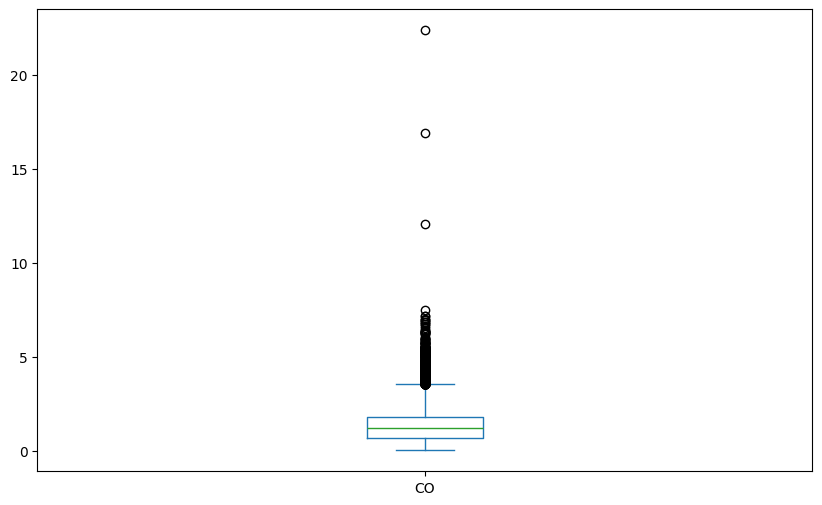

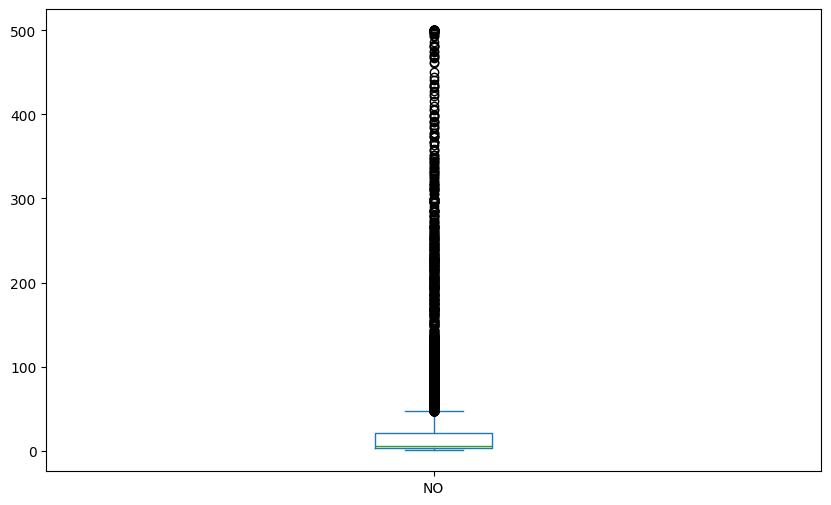

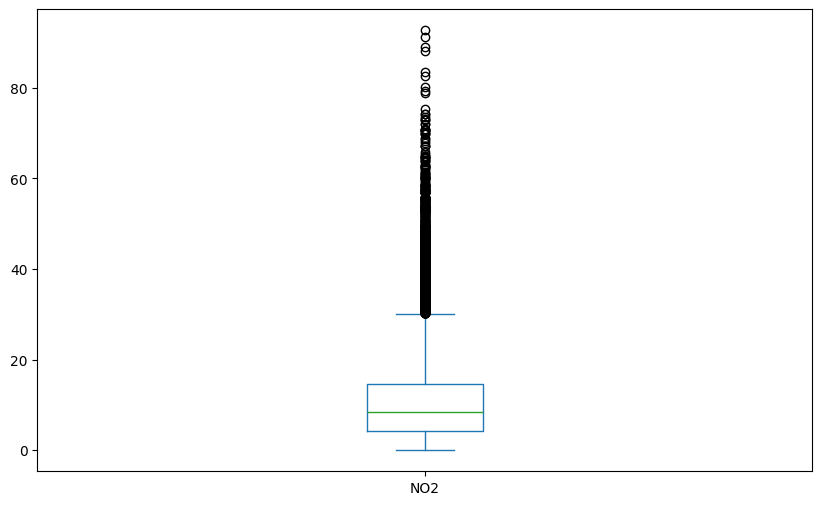

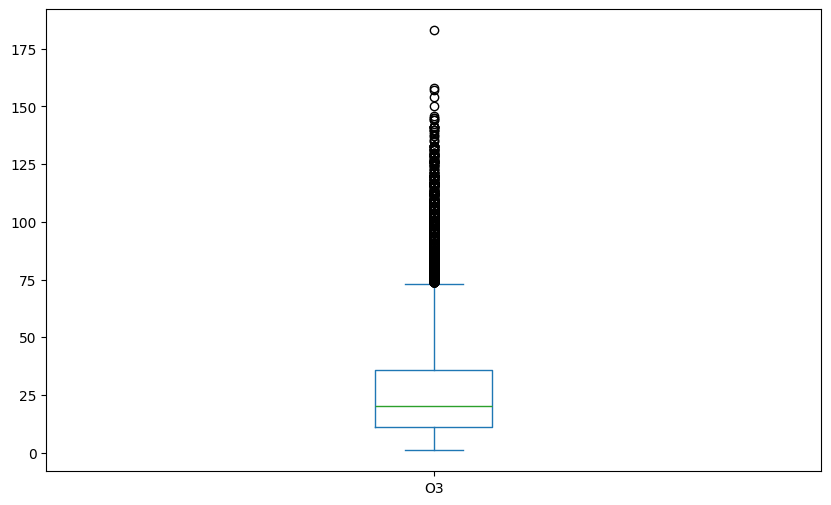

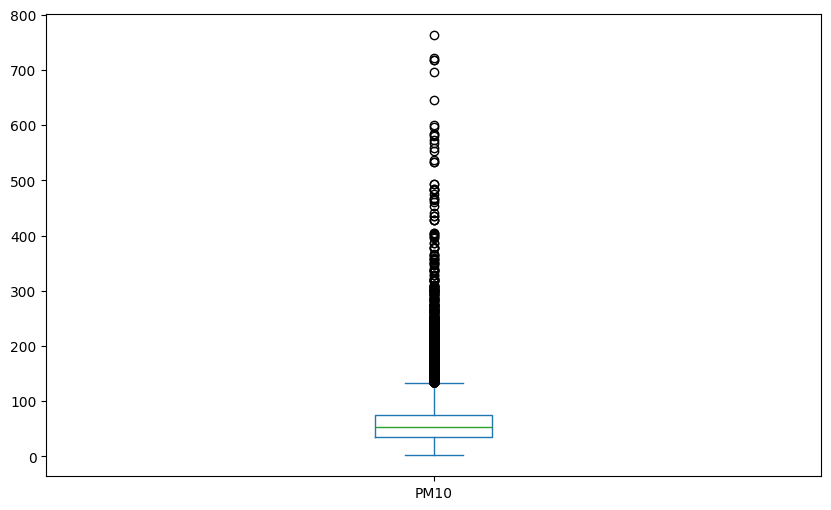

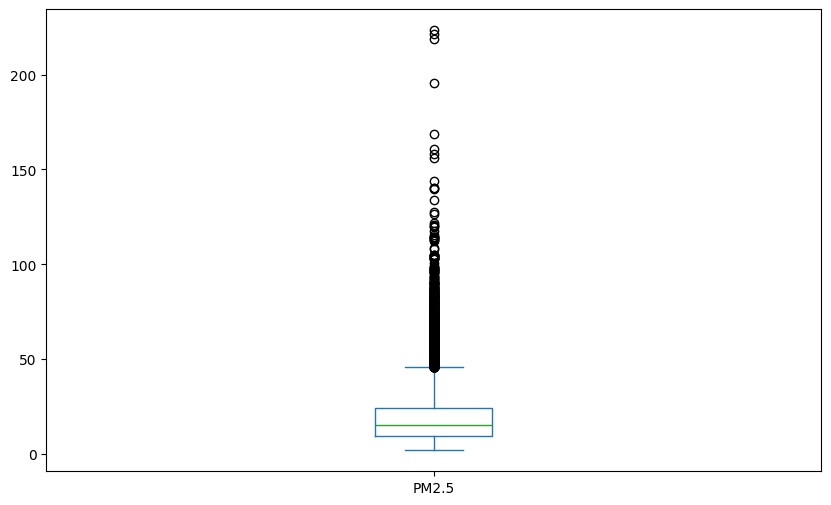

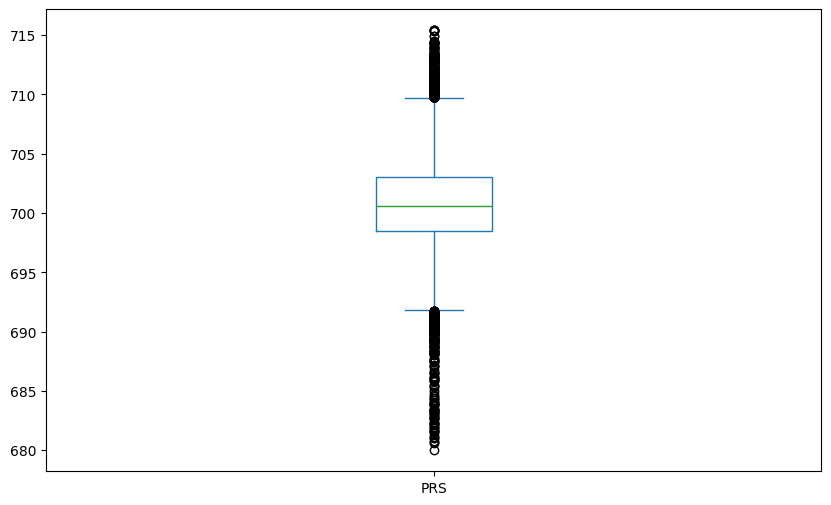

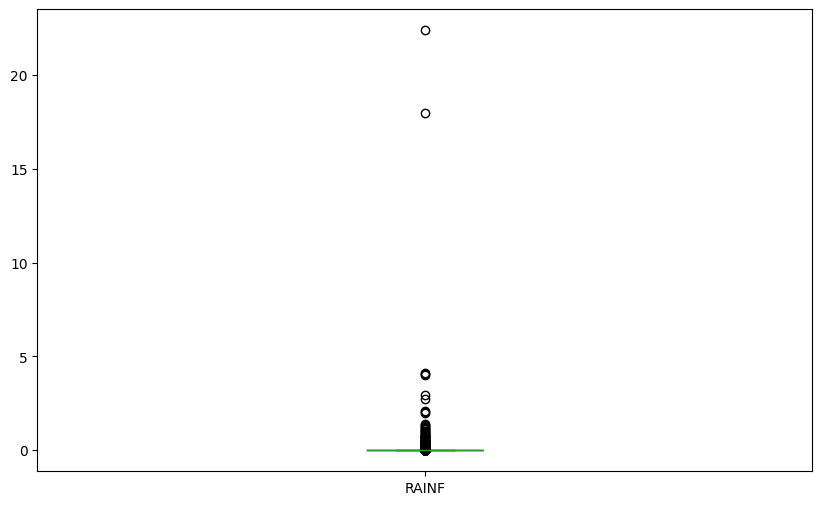

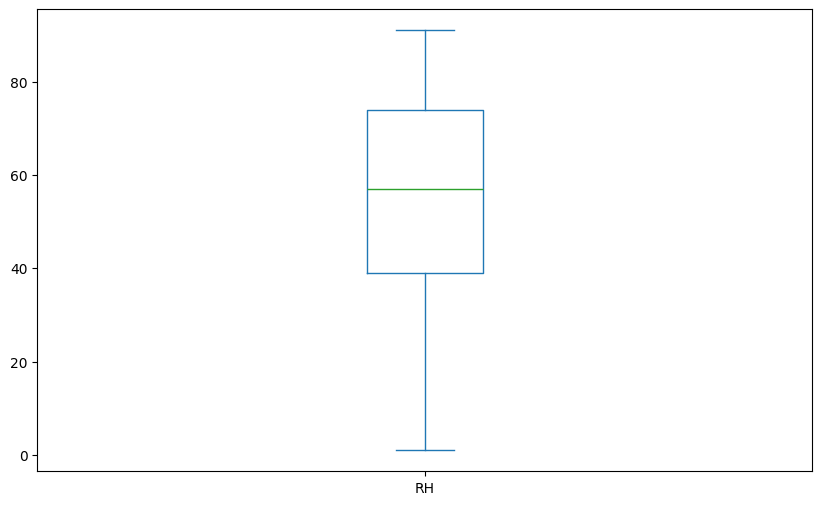

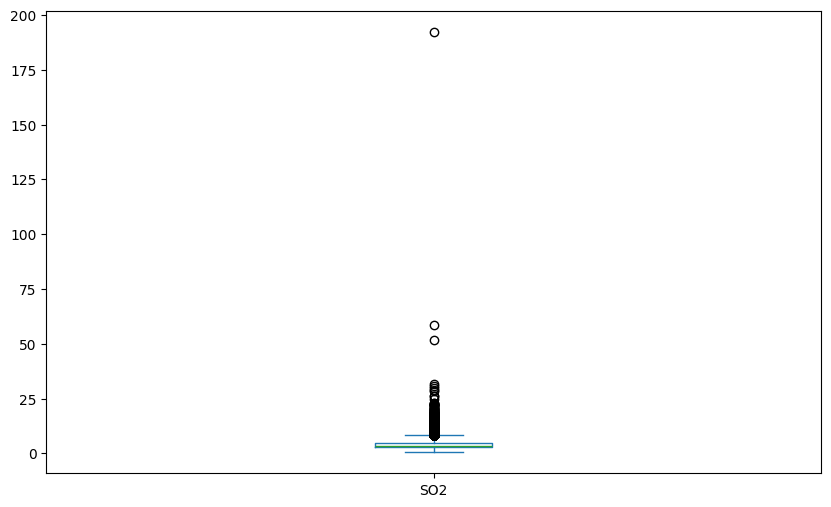

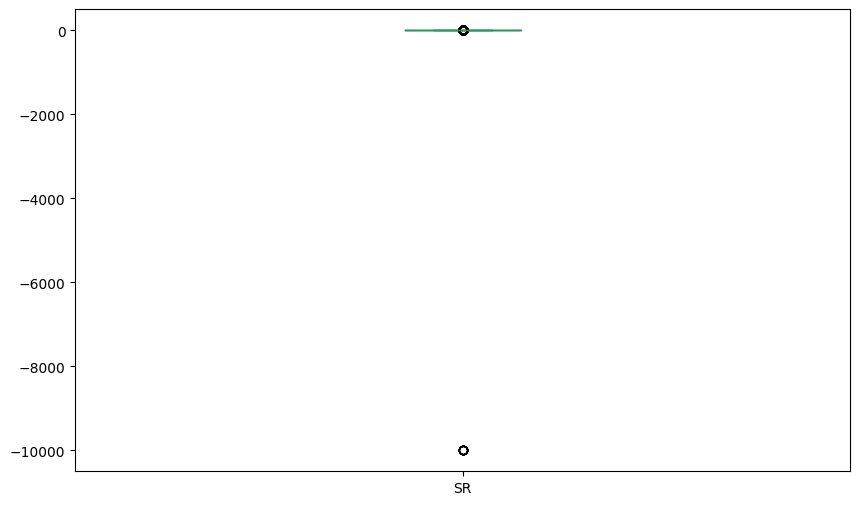

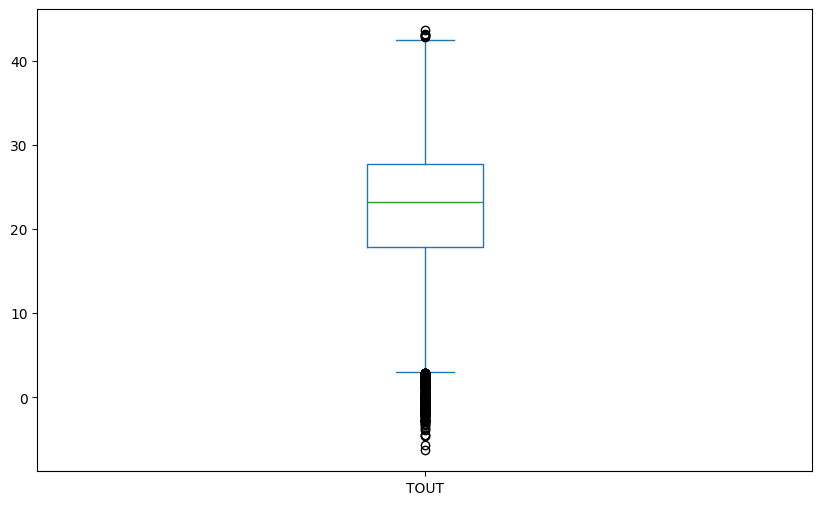

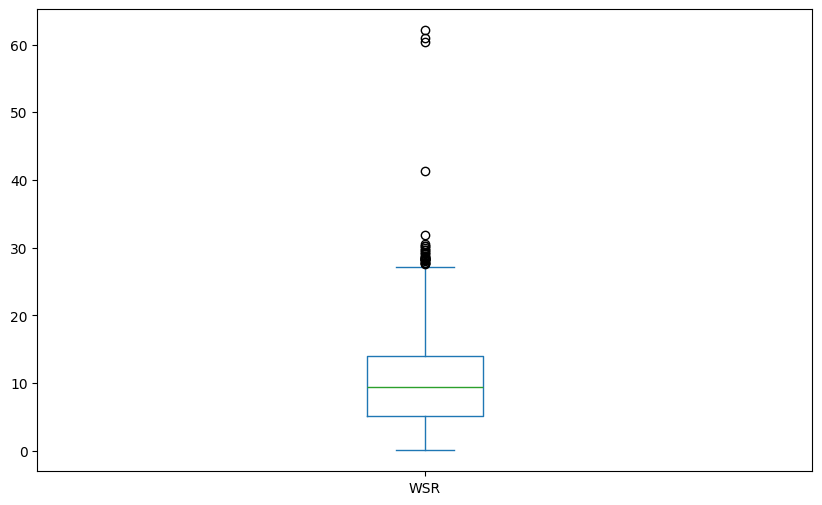

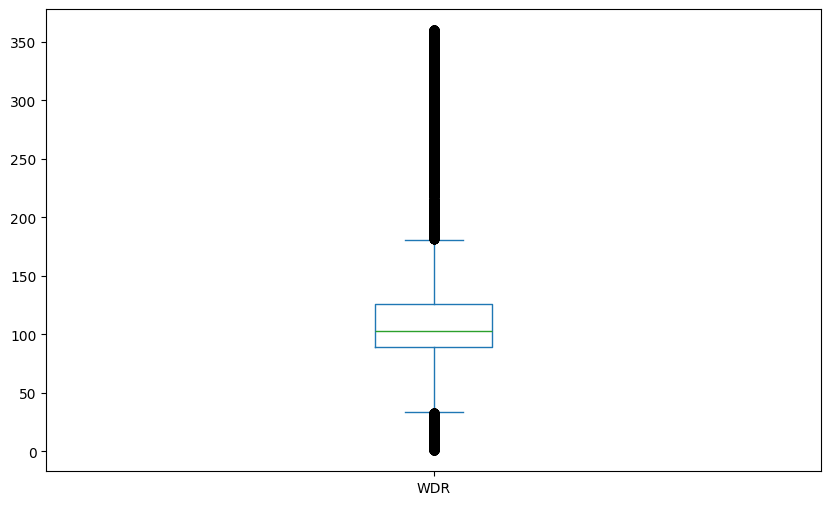

In [76]:
for col in columnas_numericas:
    plt.figure(figsize=(10,6))
    NO2[col].plot(kind='box')
    plt.show()

Parece que hay datos completamente erróneos que se deben de eliminar basándonos en los valores posibles proporcionados por SIMA.

In [77]:
"""
Valores posibles de las variables:
PM10: 0-999
PM2.5: 0-999
O3: 0-185
NO: 0-500
NO2: 0-200
SO2: 0-405
C0: 0-20
RH: 0-100
WSR: 0-75
TEMP: -6.5-45.5
SR: 0-1.26
WDR: 0-360
RAINF: 0-80
"""


'\nValores posibles de las variables:\nPM10: 0-999\nPM2.5: 0-999\nO3: 0-185\nNO: 0-500\nNO2: 0-200\nSO2: 0-405\nC0: 0-20\nRH: 0-100\nWSR: 0-75\nTEMP: -6.5-45.5\nSR: 0-1.26\nWDR: 0-360\nRAINF: 0-80\n'

In [78]:
# Rangos validos segun SIMA. Los valores fuera de estos limites se reemplazan por NaN.
rangos_validos = {
    'PM10': (0, 999),
    'PM2.5': (0, 999),
    'O3': (0, 185),
    'NO': (0, 500),
    'NO2': (0, 200),
    'SO2': (0, 405),
    'CO': (0, 20),
    'RH': (0, 100),
    'WSR': (0, 75),
    'TOUT': (-6.5, 45.5),
    'SR': (0, 1.26),
    'WDR': (0, 360),
    'RAINF': (0, 80)
}

for nombre, estacion in zip(['NO2', 'NO3', 'SO', 'NE3', 'SE3'], estaciones):
    valores_eliminados = 0

    for columna, (minimo, maximo) in rangos_validos.items():
        if columna in estacion.columns:
            valores = pd.to_numeric(estacion[columna], errors='coerce')
            fuera_de_rango = (valores < minimo) | (valores > maximo)
            valores_eliminados += fuera_de_rango.sum()
            estacion.loc[fuera_de_rango, columna] = pd.NA

    print(f'{nombre}: {valores_eliminados} valores fuera de rango reemplazados por NaN')

NO2: 14 valores fuera de rango reemplazados por NaN
NO3: 160 valores fuera de rango reemplazados por NaN
SO: 228 valores fuera de rango reemplazados por NaN
NE3: 44 valores fuera de rango reemplazados por NaN
SE3: 6 valores fuera de rango reemplazados por NaN


A continuación tenemos estadísticos relevantes para el análisis de nuestras variables:

In [79]:
for i, estacion in enumerate(estaciones):
    print(f"Dataframe {i}:")
    print("Tipo de dato")
    print(estacion.info())
    print("Estadísticos descriptivos:")
    print(estacion.describe())


Dataframe 0:
Tipo de dato
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48179 entries, 0 to 48178
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   anio    48179 non-null  int64  
 1   date    48179 non-null  object 
 2   CO      46781 non-null  float64
 3   NO      42808 non-null  float64
 4   NO2     40518 non-null  float64
 5   O3      44765 non-null  float64
 6   PM10    46802 non-null  float64
 7   PM2.5   41016 non-null  float64
 8   PRS     46203 non-null  float64
 9   RAINF   47284 non-null  float64
 10  RH      45843 non-null  float64
 11  SO2     42544 non-null  float64
 12  SR      38438 non-null  float64
 13  TOUT    46933 non-null  float64
 14  WSR     46153 non-null  float64
 15  WDR     44491 non-null  float64
dtypes: float64(14), int64(1), object(1)
memory usage: 5.9+ MB
None
Estadísticos descriptivos:
               anio            CO            NO           NO2            O3  \
count  48179.000000  4678

Ahora contamos la cantidad de valores faltantes de cada variable en cada dataframe:

In [80]:
for i, estacion in enumerate(estaciones):
    print(f"\n Porcentaje de valores faltantes en el dataframe #{i}:")
    missing_percentage = estacion.isnull().sum() / len(estacion) * 100
    print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


 Porcentaje de valores faltantes en el dataframe #0:
SR       20.218352
NO2      15.901119
PM2.5    14.867473
SO2      11.695967
NO       11.148011
WDR       7.654787
O3        7.086075
RH        4.848585
WSR       4.205152
PRS       4.101372
CO        2.901679
PM10      2.858092
TOUT      2.586189
RAINF     1.857656
dtype: float64

 Porcentaje de valores faltantes en el dataframe #1:
PM2.5    89.679731
RH       35.543661
NO       30.925418
NO2      30.810404
CO       11.678315
WSR      10.245068
O3        8.533133
SO2       6.900823
PM10      4.817305
WDR       2.052552
SR        1.358047
PRS       1.189950
TOUT      1.172255
RAINF     1.123596
dtype: float64

 Porcentaje de valores faltantes en el dataframe #2:
CO       14.079640
NO2      11.750380
PM2.5    10.324514
O3       10.320351
NO        9.643846
WDR       8.257530
SO2       7.697592
RH        6.971129
PRS       6.869133
TOUT      4.612727
WSR       4.323390
RAINF     3.599009
PM10      3.305510
SR        2.912096
dtype: flo

### Manejo de valores faltantes

Basado en el análisis de la cantidad de valores faltantes, haremos lo siguiente:

1. Ignorar las columnas con una gran cantidad de datos faltantes. En este caso, las estaciones NO3 y NE3 tienen casi todos los datos faltantes de PM2.5, por lo que aunque hagamos imputación de datos no obtendríamos información significativa de un análisis al respecto.

In [81]:
estaciones[3] = estaciones[3].drop(columns=['PM2.5'])
estaciones[1] = estaciones[1].drop(columns=['PM2.5'])

2.  Convertir la columna de la fecha a un tipo de dato de fecha para poder trabajarla como tal (Esto es necesario para hacer la interpolación)

In [82]:
for i, estacion in enumerate(estaciones):
    estacion['date'] = pd.to_datetime(estacion['date'])
    estacion = estacion.sort_values(by='date')

    #Guardar los cambios realizados
    estaciones[i] = estacion


3.  Aplicar una interpolación cuadrática para rellenar los valores faltantes que nos quedan en las filas numéricas. Como nuestros datos están basados en una línea de tiempo, es una buena idea usar este tipo de interpolación para estimar el dato de un punto basado en los valores cercanos.

In [83]:
for i, estacion in enumerate(estaciones):
    numeric_cols = estacion.select_dtypes(include=['float64', 'int64']).columns

    for col in numeric_cols:
        if estacion[col].isnull().any():
            estacion[col] = estacion[col].interpolate(method='quadratic', limit_direction='both')
            estacion[col] = estacion[col].clip(lower=0)

    # Guardar los cambios
    estaciones[i] = estacion

Ahora, comprobamos que los datos faltantes estén rellenados:

In [84]:
for i, estacion in enumerate(estaciones):
    print(f"\n Columnas con valores faltantes en el dataframe #{i}:")
    missing_percentage = estacion.isnull().sum() / len(estacion) * 100
    print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


 Columnas con valores faltantes en el dataframe #0:
NO       7.399489
NO2      6.531891
SO2      2.015401
O3       0.099628
CO       0.002076
RAINF    0.002076
PRS      0.002076
RH       0.002076
TOUT     0.002076
WSR      0.002076
WDR      0.002076
dtype: float64

 Columnas con valores faltantes en el dataframe #1:
NO     24.219234
NO2    22.396709
dtype: float64

 Columnas con valores faltantes en el dataframe #2:
RH       4.600237
WDR      0.149872
CO       0.004163
NO2      0.004163
NO       0.004163
PRS      0.004163
O3       0.004163
RAINF    0.004163
SO2      0.004163
TOUT     0.004163
WSR      0.004163
dtype: float64

 Columnas con valores faltantes en el dataframe #3:
SO2      2.295698
CO       1.828432
NO       1.828432
NO2      1.828432
PRS      0.002539
RAINF    0.002539
dtype: float64

 Columnas con valores faltantes en el dataframe #4:
SO2      0.029059
NO       0.002076
CO       0.002076
NO2      0.002076
O3       0.002076
RAINF    0.002076
PRS      0.002076
RH       0.

Como el código está hecho para que solo imprima una columna si hay más de 0% de datos faltantes, las respuestas vacías significan que ya no faltan datos por rellenar.

### Transformación de los datos

Ahora, aplicaremos una serie de transformaciones a nuestro dataset para mejorar su interpretabilidad y su utilidad para futuros análisis:

1. Transformar las fechas a tipo de dato de fecha (ya se hizo).

2. Discretizar la cantidad de lluvia y radiación solar

Actualmente, la cantidad de lluvia y la radiación solar arrojan valores que tienen una mínima de 0 y una media cercana a 0. Esto nos indica que una gran cantidad de los valores registrados son 0 o cercanos a 0. Esto nos indica que nuestra distribución está muy sesgada, y para poder medir su impacto mejor haremos binning con nuestros nuevos valores entre 0 y 3 (4 categorías posibles).

In [85]:
import numpy as np

def bin_quartiles_with_zero(series, num_bins=3):

    binned_series = pd.Series(0, index=series.index, dtype=float) # Initialize with 0
    non_zero_values = series[series > 0]

    if not non_zero_values.empty:
        if non_zero_values.nunique() >= num_bins:
            qcut_bins = pd.qcut(non_zero_values, q=num_bins, labels=False, duplicates='drop') + 1
            binned_series.loc[series > 0] = qcut_bins

    return binned_series.astype('category')


for i, estacion in enumerate(estaciones):
    print(f"Binning realizado acorde al percentil para la dataframe {i}:")

    if 'RAINF' in estacion.columns:
        estacion['RAINF_binned_quartile'] = bin_quartiles_with_zero(estacion['RAINF'])
        print(f"\nDatos de RAINF para la dataframe {i}:\n{estacion['RAINF_binned_quartile'].value_counts(dropna=False).sort_index()}")

    if 'SR' in estacion.columns:
        estacion['SR_binned_quartile'] = bin_quartiles_with_zero(estacion['SR'])
        print(f"\nDatos de SR para la dataframe {i}:\n{estacion['SR_binned_quartile'].value_counts(dropna=False).sort_index()}")

    estaciones[i] = estacion


Binning realizado acorde al percentil para la dataframe 0:

Datos de RAINF para la dataframe 0:
RAINF_binned_quartile
0.0    47596
1.0      200
2.0      196
3.0      187
Name: count, dtype: int64

Datos de SR para la dataframe 0:
SR_binned_quartile
0.0    27905
1.0     6758
2.0     6805
3.0     6711
Name: count, dtype: int64
Binning realizado acorde al percentil para la dataframe 1:

Datos de RAINF para la dataframe 1:
RAINF_binned_quartile
0.0    22606
Name: count, dtype: int64

Datos de SR para la dataframe 1:
SR_binned_quartile
0.0    10695
1.0     3973
2.0     3981
3.0     3957
Name: count, dtype: int64
Binning realizado acorde al percentil para la dataframe 2:

Datos de RAINF para la dataframe 2:
RAINF_binned_quartile
0.0    46708
1.0      759
2.0      168
3.0      406
Name: count, dtype: int64

Datos de SR para la dataframe 2:
SR_binned_quartile
0.0    23988
1.0     8035
2.0     8020
3.0     7998
Name: count, dtype: int64
Binning realizado acorde al percentil para la dataframe 3: